In [1]:
import helper
import pandas as pd
from utils import *

import time
import numpy as np
import math
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torch import nn

from IPython.display import Image


# Data

### Import dataset

In [2]:
data = pd.read_csv('features_target.csv')
data['Unnamed: 0'] = pd.to_datetime(data['Unnamed: 0'])
data.rename(columns = {'Unnamed: 0':'Date'}, inplace = True) 
#data.set_index('Date', inplace = True)
thirty_day_data = data['SP500 30 Day Volatility']
VIX_data = data['VIX']
price_data = data['SP500']
print(len(data))
data
returns = 100 * price_data.pct_change().dropna()
returns = returns.drop(returns[returns == 0].index)
closes = pd.DataFrame(price_data)
cum_rets = closes / closes.iloc[0,:]
cum_rets
daily_vol = returns.std()
#21 trading days per month
monthly_vol = math.sqrt(21) * daily_vol
#252 trading days per year
yearly_vol = math.sqrt(252) * daily_vol
mlvols = abs(returns.rolling(window = 30, min_periods = 30).std().dropna())
data['mlvols'] = mlvols.shift(-1)
data.dropna(inplace=True)
data['mlvols']

2264


30      1.186285
31      1.188293
32      1.177692
33      1.180504
34      1.185499
          ...   
2258    0.805295
2259    0.805093
2260    0.843017
2261    0.843943
2262    0.870318
Name: mlvols, Length: 2232, dtype: float64

We identify the dependent and independent variables:

In [3]:
df = data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2232 entries, 30 to 2262
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Date                           2232 non-null   datetime64[ns]
 1   SP500                          2232 non-null   float64       
 2   SP500 Log Returns              2232 non-null   float64       
 3   SP500 30 Day Volatility        2232 non-null   float64       
 4   SPX Put Call Ratio             2232 non-null   float64       
 5   SPX Put Volume                 2232 non-null   float64       
 6   SPX Call Volume                2232 non-null   float64       
 7   Total SPX Options Volume       2232 non-null   float64       
 8   VIX                            2232 non-null   float64       
 9   DJIA                           2232 non-null   float64       
 10  NASDAQ                         2232 non-null   float64       
 11  10Y_Treasury         

In [4]:
target = "mlvols"

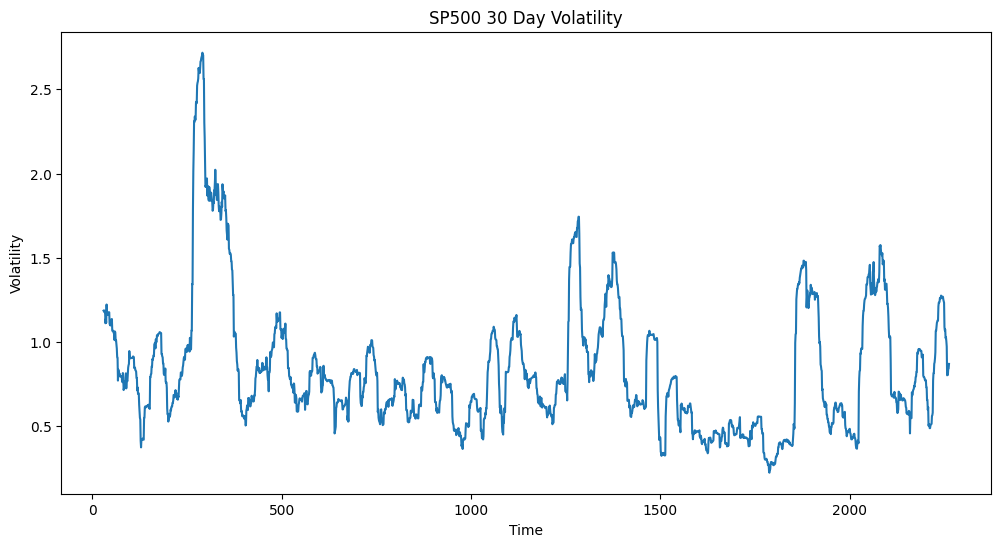

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df[target])
plt.title('SP500 30 Day Volatility')
plt.xlabel('Time')
plt.ylabel('Volatility')
plt.show()

### Reduce the number of columns

In [6]:
df.drop(columns=[
 'Consumer_Sentiment_log_change',
 'DJIA_log_returns',
 'Gold_log_returns',
 'MSCI_World_log_returns',
 'NASDAQ_log_returns',
 'Oil_log_returns',
 'RUSSELL_log_returns',
 'SP500 Log Returns',
 'SP500_call_log_change',
 'SP500_put_log_change',
 'SP500_total_opts_log_change',
 'SPX Put Volume',
 'USD_Index_log_returns',
 'EMB_Yield',
 'MSCI_World',
 'RUSSELL',
 'SPX Call Volume',
 'Total SPX Options Volume',
 'Date'
 ]
 , inplace=True)
df[target] = mlvols.shift(-1)
df.dropna(inplace=True)
features = list(df.columns.difference([target]))
#features = ['Close']
features

['10Y_Treasury',
 'Consumer_Sentiment',
 'DJIA',
 'Gold',
 'High_Yield_Bonds',
 'NASDAQ',
 'Oil',
 'SP500',
 'SP500 30 Day Volatility',
 'SPX Put Call Ratio',
 'USD_Index',
 'VIX']

Text(0.5, 1.0, 'Volatilité mobile sur 30 jours du rendement journalier du S&P 500')

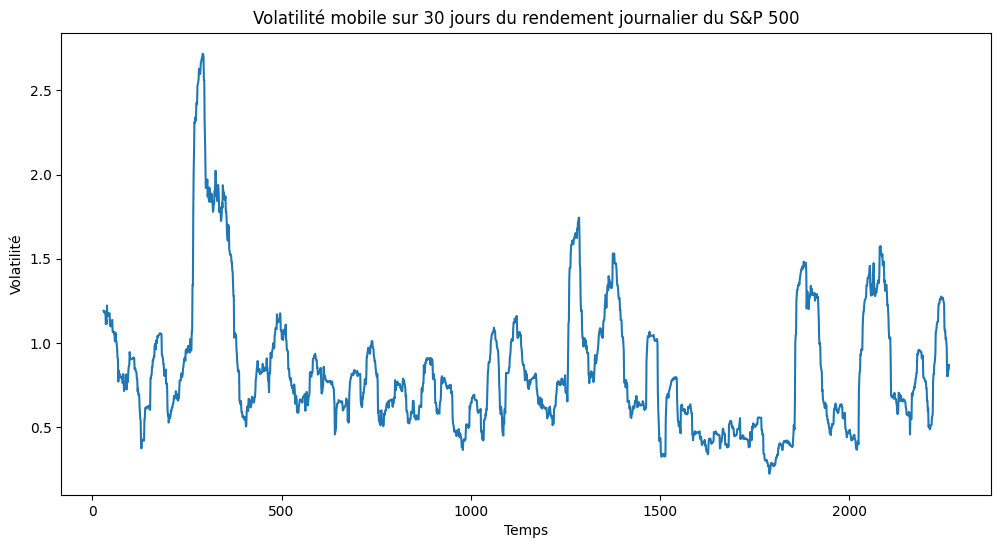

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(mlvols, label = "Real")
plt.xlabel('Temps')
plt.ylabel('Volatilité')
plt.title('Volatilité mobile sur 30 jours du rendement journalier du S&P 500')

## Data Processing

In [8]:
df

,SP500,SP500 30 Day Volatility,SPX Put Call Ratio,VIX,DJIA,NASDAQ,10Y_Treasury,High_Yield_Bonds,Consumer_Sentiment,USD_Index,Gold,Oil,mlvols
30,1075.63,19.208314,1.31,26.44,10271.21,2178.95,2.579,8.30,68.9,82.45,1235.4,74.45,1.186285
31,1071.69,19.463018,2.03,25.49,10213.62,2179.76,2.612,8.34,68.9,83.06,1228.8,73.45,1.188293
32,1067.36,19.946457,1.78,25.66,10174.41,2159.63,2.607,8.33,68.9,83.12,1228.5,72.71,1.177692
33,1051.87,21.591283,0.87,27.46,10040.45,2123.76,2.499,8.36,68.9,83.15,1233.4,71.24,1.180504
34,1055.33,22.813718,1.97,26.70,10060.06,2141.54,2.538,8.40,68.9,83.26,1241.3,72.07,1.185499
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2258,2961.79,48.386310,2.31,17.22,26820.25,7939.63,1.675,5.62,93.2,99.13,1506.4,55.95,0.805295
2259,2976.74,47.065115,2.26,16.24,26916.83,7999.34,1.675,5.65,93.2,99.38,1472.9,54.09,0.805093
2260,2940.25,46.781249,2.07,18.56,26573.04,7908.68,1.644,5.66,95.5,99.13,1489.0,53.60,0.843017
2261,2887.61,47.359805,1.82,20.56,26078.62,7785.25,1.596,5.80,95.5,99.02,1507.9,52.67,0.843943


To process the data, we first split it into training and test data, where two-thirds of the data is used for training, and the last third is used for testing.

In [9]:
size = int(len(df) * 0.75)

#df = df.iloc[:2000]

df_train = df.loc[:size].copy()
df_test = df.loc[size:2000].copy()

Next, in order to ensure that some values due to their mangnitude do not inherently dominate the features, we standardize their values.

In [10]:
target_mean = df_train[target].mean()
target_stdev = df_train[target].std()

for c in df_train.columns:
    mean = df_train[c].mean()
    stdev = df_train[c].std()

    df_train[c] = (df_train[c] - mean) / stdev
    df_test[c] = (df_test[c] - mean) / stdev

In [11]:
from Factory import SequenceDataset

Finally, the last step in the data processing to prepare for LSTM is to prepare the data in a sequence of past observations. Preparation of the LSTM on time series data means that it uses a certain number of past observations to predict the future. In this case, the sequence length decides how many days the LSTM considers in advance. If the sequence length is $n$, then the LSTM considers the last $n$ observations to predict the $n+1$th day.

We decided the sequence length as 3 for purposes of this notebook.

In [12]:
torch.manual_seed(101)

batch_size = 1
sequence_length = 3

train_dataset = SequenceDataset(
    df_train,
    target=target,
    features=features,
    sequence_length=sequence_length
)
test_dataset = SequenceDataset(
    df_test,
    target=target,
    features=features,
    sequence_length=sequence_length
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

X, y = next(iter(train_loader))

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: torch.Size([1, 3, 12])
Target shape: torch.Size([1])


# Classical LSTM

We first define two functions:
    
- train_model: function to train the model based on the batches of data
- test_model: function to test the model on the testing data
    
We print the loss at the end to understand how the model is performing with regards to the data.

In [13]:
def train_model(data_loader, model, loss_function, optimizer):
    num_batches = len(data_loader)
    total_loss = 0
    model.train()
    
    for X, y in data_loader:
        output = model(X)
        loss = loss_function(output, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / num_batches
    print(f"Train loss: {avg_loss}")
    return avg_loss

def test_model(data_loader, model, loss_function):
    
    num_batches = len(data_loader)
    total_loss = 0

    model.eval()
    with torch.no_grad():
        for X, y in data_loader:
            output = model(X)
            total_loss += loss_function(output, y).item()

    avg_loss = total_loss / num_batches
    print(f"Test loss: {avg_loss}")
    return avg_loss

## Running the Classical LSTM

To understand our implementation of QLSTM, we first explain our implementation LSTM. LSTM follows the following structure:

<img src="lstm2.jpg" alt="drawing" width="400"/>

Image taken from: Quantum Long Short-Term Memory, https://arxiv.org/pdf/2009.01783.pdf (Samuel Yen-Chi Chen, Shinjae Yoo, and Yao-Lung L. Fang (2020)) 

Simply put, LSTM uses 4 neural network layers in each LSTM cell. They are:

- Forget layer
- Input layer
- Update layer
- Output layer

We can see the corresponding layers in the W cells in the picture above. We will be skipping the technical details, but it is important to note that these 4 layers are the keys to building an LSTM neural network model that we can train and eventually use to predict. They usually take the form of a normal NN layer (like a linear layer with reLU or convolutional layers).

LSTMs are well studied, and there is a native implementation of it in PyTorch to begin with, so we use a slightly modified version of it for the time series LSTM that we perform here. The code for the time series LSTM was reused from:

How to use PyTorch LSTMs for time series regression: https://www.crosstab.io/articles/time-series-pytorch-lstm, Brian Kent.

In the following code, we train LSTM to predict future stock prices, and then test it on the test dataset. The learning rate of 0.0001 was decided after some experimentation, where we chose the learning rate that gave accurate results. The number of epochs we use is 20, by which it would have converged and thus would suffice for the purposes of this notebook. After that, we visualize three different graphs: the comparison between the real stock prices and the ones given by the model; and the evolution of test loss and training loss by epoch.

In [14]:
from Factory import ShallowRegressionLSTM

In [15]:
learning_rate = 0.0001
num_hidden_units = 2

model = ShallowRegressionLSTM(num_sensors=len(features), hidden_units=num_hidden_units)
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [16]:
classical_loss_train = []
classical_loss_test = []
print("Untrained test\n--------")
test_loss = test_model(test_loader, model, loss_function)
print()
classical_loss_test.append(test_loss)

for ix_epoch in range(10):
    print(f"Epoch {ix_epoch}\n---------")
    train_loss = train_model(train_loader, model, loss_function, optimizer=optimizer)
    test_loss = test_model(test_loader, model, loss_function)
    print()
    classical_loss_train.append(train_loss)
    classical_loss_test.append(test_loss)

Untrained test
--------
Test loss: 0.7947851723597434

Epoch 0
---------
Train loss: 1.1354997759816199
Test loss: 0.7979836527347733

Epoch 1
---------
Train loss: 0.9367725441284784
Test loss: 0.7966498351494345

Epoch 2
---------
Train loss: 0.7987808182098363
Test loss: 0.7939056556270873

Epoch 3
---------
Train loss: 0.7250633710007732
Test loss: 0.7922344027522449

Epoch 4
---------
Train loss: 0.6792350427936403
Test loss: 0.7916063920409885

Epoch 5
---------
Train loss: 0.6438777586092396
Test loss: 0.7911551985300699

Epoch 6
---------
Train loss: 0.6110918395830549
Test loss: 0.7893335926290062

Epoch 7
---------
Train loss: 0.5818962935031005
Test loss: 0.7844657598267878

Epoch 8
---------
Train loss: 0.5568232710148788
Test loss: 0.7800334380135554

Epoch 9
---------
Train loss: 0.5341062216645316
Test loss: 0.7771791772335749



We then use the model to predict the test set, and then compare the results of the prediction to the real values.

In [17]:
def predict(data_loader, model):
    """Just like `test_loop` function but keep track of the outputs instead of the loss
    function.
    """
    output = torch.tensor([])
    model.eval()
    with torch.no_grad():
        for X, _ in data_loader:
            y_star = model(X)
            output = torch.cat((output, y_star), 0)
    
    return output

In [18]:
train_eval_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

ystar_col = "Model forecast"
df_train[ystar_col] = predict(train_eval_loader, model).numpy()
df_test[ystar_col] = predict(test_loader, model).numpy()

df_out = pd.concat((df_train, df_test))[[target, ystar_col]]

for c in df_out.columns:
    df_out[c] = df_out[c] * target_stdev + target_mean

print(df_out)
#df_out = df_out[1515:1815]

        mlvols  Model forecast
30    1.186285        1.086924
31    1.188293        1.113875
32    1.177692        1.116176
33    1.180504        1.099744
34    1.185499        1.125553
...        ...             ...
1996  0.472090        0.557302
1997  0.473948        0.561942
1998  0.472713        0.557989
1999  0.483508        0.552715
2000  0.485083        0.553004

[1971 rows x 2 columns]


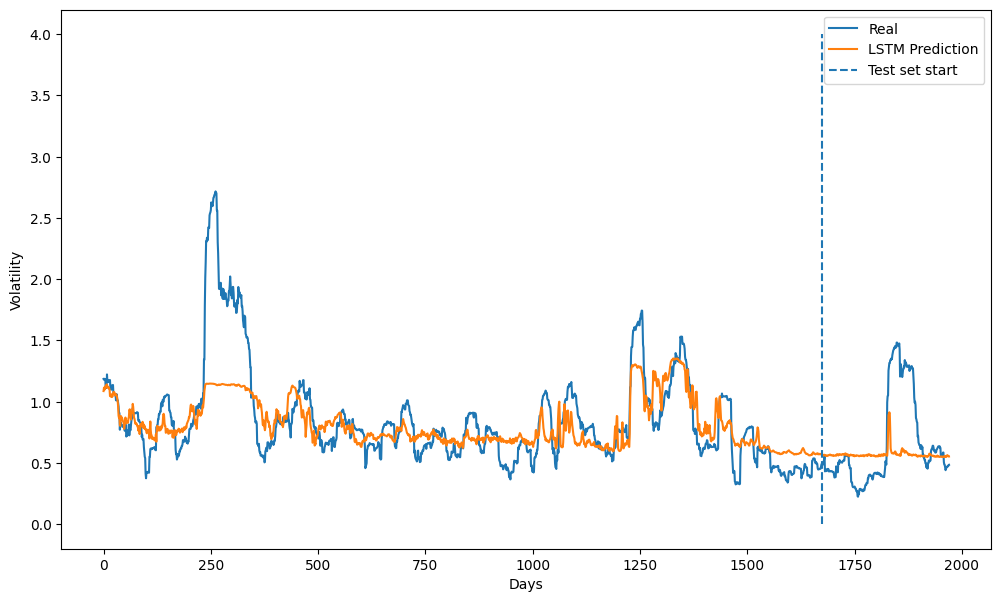

In [19]:
plt.figure(figsize=(12, 7))
plt.plot(range(df_out.shape[0]), df_out[target], label = "Real")
plt.plot(range(df_out.shape[0]), df_out["Model forecast"], label = "LSTM Prediction")
#plt.plot(range(df_out.shape[0]), df_out[target].shift(1), label='LastValue')
plt.ylabel('Volatility')
plt.xlabel('Days')
#plt.xticks(ticks=range(df_out.shape[0]))  # Un tick tous les ~3% des données
#plt.grid()
plt.vlines(size, ymin = 0, ymax = 4, label = "Test set start", linestyles = "dashed")
plt.legend()
plt.show()

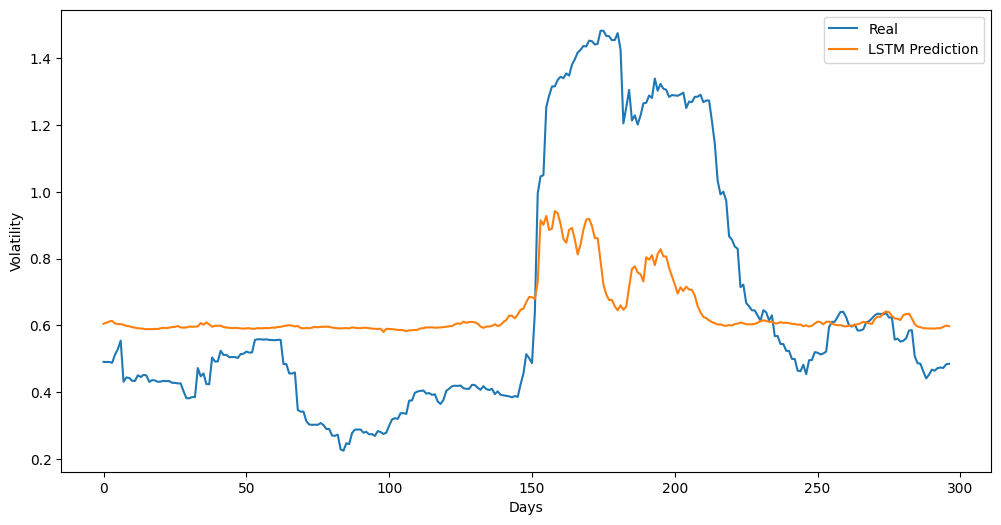

In [95]:
df_out = df_out[size:]
plt.figure(figsize=(12, 6))
plt.plot(range(df_out.shape[0]), df_out[target], label = "Real")
plt.plot(range(df_out.shape[0]), df_out["Model forecast"], label = "LSTM Prediction")
#plt.plot(range(df_out.shape[0]), df_out[target].shift(1), label='LastValue')
plt.ylabel('Volatility')
plt.xlabel('Days')
#plt.xticks(ticks=range(df_out.shape[0]))  # Un tick tous les ~3% des données
#plt.grid()
#plt.vlines(df_out.shape[0], ymin = 0, ymax = 4, label = "Test set start", linestyles = "dashed")
plt.legend()
plt.show()

In [96]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error

res = pd.DataFrame({
    'Forecast' : df_out['Model forecast'],
    'Real' : df_out[target]
}
)
res['real_return'] = res['Real'] - res['Real'].shift(1)
res['forecast_return'] = res['Forecast'] - res['Real'].shift(1)

res['move_forecast'] = res['real_return'] >= 0
res['move_real'] = res['forecast_return'] >= 0
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# 🔹 Calcul de l'accuracy
accuracy = accuracy_score(res['move_real'], res['move_forecast'])
mse = mean_squared_error(res['Forecast'], res['Real'])
print(f"📊 Accuracy du modèle pour la direction : {accuracy:.2%}")
print(f"📊 MSE du modèle pour la direction : {mse}")
print('Nombre de paramètres du modèle : ', total_params)


res.head(20)

📊 Accuracy du modèle pour la direction : 48.82%
📊 MSE du modèle pour la direction : 0.09239801206964683
Nombre de paramètres du modèle :  131


,Forecast,Real,real_return,forecast_return,move_forecast,move_real
1704,0.605023,0.490961,NaN,NaN,False,False
1705,0.608155,0.490456,-0.000505,0.117194,False,True
1706,0.611803,0.490701,0.000244,0.121347,True,True
1707,0.613537,0.488064,-0.002636,0.122837,False,True
1708,0.605813,0.512131,0.024067,0.117749,True,True
1709,0.604311,0.529003,0.016871,0.092179,True,True
1710,0.603838,0.554457,0.025454,0.074835,True,True
1711,0.601739,0.431321,-0.123136,0.047282,False,True
1712,0.598801,0.444208,0.012887,0.167480,True,True
1713,0.597603,0.442517,-0.001691,0.153395,False,True


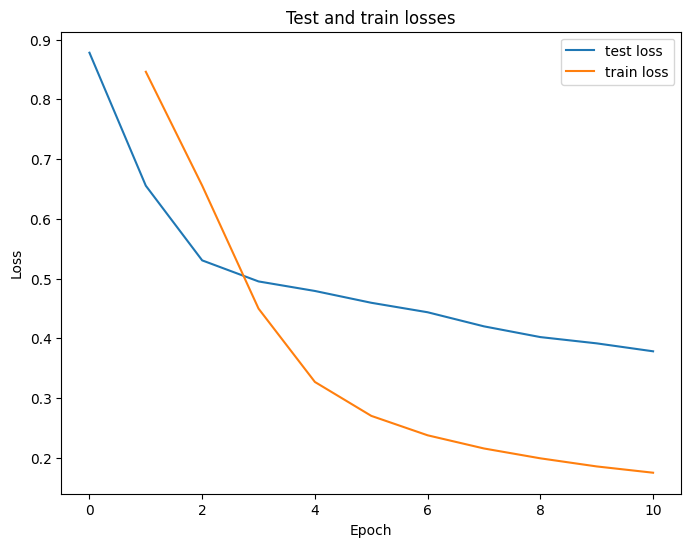

In [89]:
plt.figure(figsize=(8, 6))
plt.plot(range(11), classical_loss_test, label='test loss')
plt.plot(range(1, 11), classical_loss_train, label='train loss')
plt.ylabel('Loss')
plt.title('Test and train losses')
plt.legend()
plt.xlabel('Epoch')
plt.show()

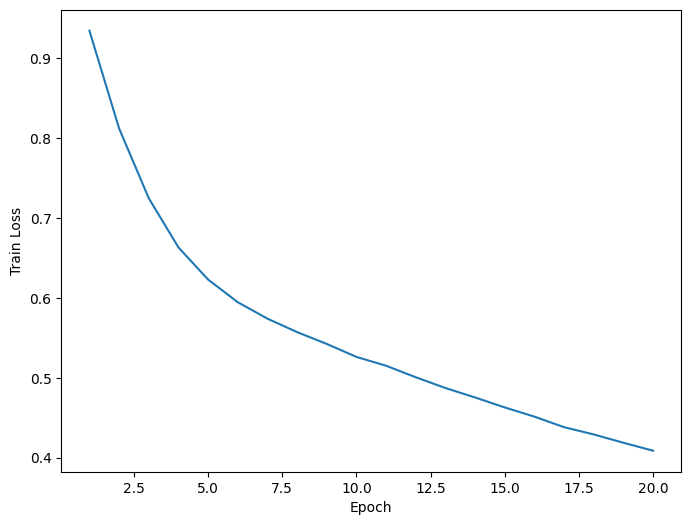

In [54]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, 21), classical_loss_train)
plt.ylabel('Train Loss')
plt.xlabel('Epoch')
plt.show()

# Running the QLSTM

To implement QLSTM, we then replace the 4 key layers of the LSTM with variational quantum layers enabled by Pennylane. The variational quantum layers are based on the following variational quantum circuits:

<img src="vqc.jpg" alt="drawing" width="600"/>

Image taken from: Quantum Long Short-Term Memory, https://arxiv.org/pdf/2009.01783.pdf. By Samuel Yen-Chi Chen, Shinjae Yoo, and Yao-Lung L. Fang

Thus, the parameters to be trained instead becomes the rotational parameters within the circuits, hence forming a hybrid quantum-classical neural network layer (as the optimizer is classical). In the paper on QLSTM, they show that the trainability of the QLSTM is better as "learns significantly more information than the LSTM does right after the first training epoch, and its loss decreases more stably and faster than that of its classical counterpart" (20). Thus, in this study, we hope to show that QLSTM has potential be more accurate and learn more per epoch than its classical counterpart. 

The code for the QLSTM was first taken from:

Example of a QLSTM: https://github.com/rdisipio/qlstm, Riccardo Di Sipio <br>

Although we have repurposed it and changed some of it to fit our purposes, for example to follow the variational quantum quantum circuits shown above. We also use the inbuilt Pennylane simulator to run these variational quantum circuits.

In the following code, we proceed to train a QLSTM model to predict the stock prices of MRK stock, which will provide a proof of concept that QLSTM not only can be used for stock prices prediction, but also has advantages over its classical counterpart. The number of qubits we use is 4, the number of variational layers used is 1, and the learning rate is 0.05. For the number of qubits, we decided on that value as we wanted to show that it was possible even on a small number of qubits; while the latter 2 parameters were decided on by experimentation on a small number of epochs to see which gave the best results. After that, we proceed to see 3 different graphs that we saw in the classical example.

In [109]:
from Factory import QShallowRegressionLSTM

In [110]:
learning_rate = 0.05
num_hidden_units = 8

Qmodel = QShallowRegressionLSTM(num_sensors=len(features), hidden_units=num_hidden_units, n_qubits=4)
loss_function = nn.MSELoss()
optimizer = torch.optim.Adagrad(Qmodel.parameters(), lr=learning_rate)

initialized QLSTM with simulation

weight_shapes = (n_qlayers, n_vrotations, n_qubits) = (1, 3, 4)
initialized a QShallowLSTM



In [111]:
quantum_loss_train = []
quantum_loss_test = []
print("Untrained test\n--------")
start = time.time()
test_loss = test_model(test_loader, Qmodel, loss_function)
end = time.time()
print("Execution time", end - start)
quantum_loss_test.append(test_loss)

for ix_epoch in range(3):
    print(f"Epoch {ix_epoch}\n---------")
    start = time.time()
    train_loss = train_model(train_loader, Qmodel, loss_function, optimizer=optimizer)
    test_loss = test_model(test_loader, Qmodel, loss_function)
    end = time.time()
    print("Execution time", end - start)
    quantum_loss_train.append(train_loss)
    quantum_loss_test.append(test_loss)

Untrained test
--------
Test loss: 1.45184532519635
Execution time 195.2435712814331
Epoch 0
---------
Train loss: 0.39309740964306245
Test loss: 0.563653468881477
Execution time 1752.2420728206635
Epoch 1
---------
Train loss: 0.22274030340363482
Test loss: 0.3276518053326343
Execution time 1966.226597070694
Epoch 2
---------
Train loss: 0.1849849652040454
Test loss: 0.3530664300298142
Execution time 2055.619596004486


In [117]:
train_eval_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

ystar_col_Q = "Model forecast"
df_train[ystar_col_Q] = predict(train_eval_loader, Qmodel).numpy()
df_test[ystar_col_Q] = predict(test_loader, Qmodel).numpy()

df_out_Q = pd.concat((df_train, df_test))[[target, ystar_col_Q]]

for c in df_out_Q.columns:
    df_out_Q[c] = df_out_Q[c] * target_stdev + target_mean

print(df_out_Q)

        mlvols  Model forecast
30    1.191692        1.341564
31    1.186285        1.231251
32    1.188293        1.249759
33    1.177692        1.401766
34    1.180504        1.365192
...        ...             ...
1996  0.464704        0.871761
1997  0.472090        0.856615
1998  0.473948        0.885650
1999  0.472713        0.871641
2000  0.483508        0.901815

[1971 rows x 2 columns]


In [120]:
df_out_Q[target].shape

(1971,)

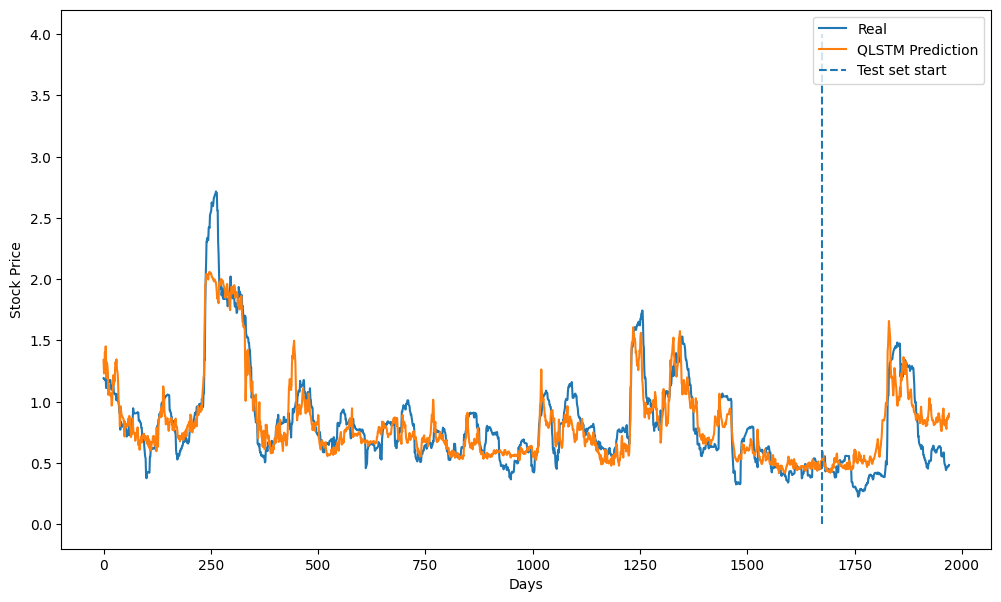

In [124]:
plt.figure(figsize=(12, 7))
plt.plot(range(1971), df_out_Q[target], label = "Real")
plt.plot(range(1971), df_out_Q['Model forecast'], label = "QLSTM Prediction")
plt.ylabel('Stock Price')
plt.xlabel('Days')
plt.vlines(size, ymin = 0, ymax = 4, label = "Test set start", linestyles = "dashed")
plt.legend()
plt.show()

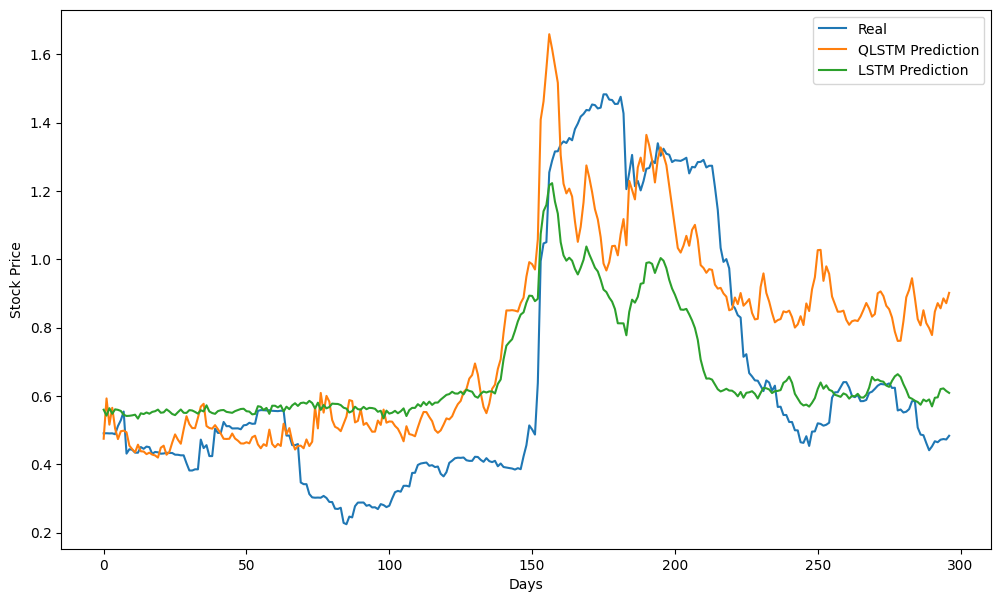

In [165]:
plt.figure(figsize=(12, 7))
plt.plot(range(297), df_out_Q[target].iloc[size:], label = "Real")
plt.plot(range(297), df_out_Q['Model forecast'].iloc[size:], label = "QLSTM Prediction")
plt.plot(range(297), df_out["Model forecast"], label = "LSTM Prediction")
plt.ylabel('Stock Price')
plt.xlabel('Days')
#plt.vlines(0, ymin = 0, ymax = 4, label = "Test set start", linestyles = "dashed")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(12, 7))
plt.plot(range(297), df_out_Q[target].iloc[size:], label = "Real")
plt.plot(range(297), df_out_Q['Model forecast'].iloc[size:], label = "QLSTM Prediction")
plt.plot(range(297), df_out["Model forecast"], label = "LSTM Prediction")
plt.ylabel('Stock Price')
plt.xlabel('Days')
plt.vlines(0, ymin = 0, ymax = 4, label = "Test set start", linestyles = "dashed")
plt.legend()
plt.show()

In [144]:
df_out_Q.iloc[size:].shape

(297, 2)

In [150]:
res = pd.DataFrame({
    'Forecast' : df_out_Q['Model forecast'].iloc[size:],
    'Real' : df_out[target]
}
)
res['real_return'] = res['Real'] - res['Real'].shift(1)
res['forecast_return'] = res['Forecast'] - res['Real'].shift(1)

res['move_forecast'] = res['real_return'] >= 0
res['move_real'] = res['forecast_return'] >= 0

# 🔹 Calcul de l'accuracy
accuracy = accuracy_score(res['move_real'], res['move_forecast'])
mse = mean_squared_error(res['Forecast'], res['Real'])
print(f"📊 Accuracy du modèle pour la direction : {accuracy:.2%}")
print(f"📊 MSE du modèle pour la direction : {mse}")
total_params_Q = sum(p.numel() for p in Qmodel.parameters() if p.requires_grad)

print("No. of parameters for QLSTM: ", total_params_Q)

res.head(20)

📊 Accuracy du modèle pour la direction : 51.18%
📊 MSE du modèle pour la direction : 0.05992531146460321
No. of parameters for QLSTM:  133


,Forecast,Real,real_return,forecast_return,move_forecast,move_real
1704,0.474927,0.490615,NaN,NaN,False,False
1705,0.592882,0.490961,0.000346,0.102267,True,True
1706,0.516083,0.490456,-0.000505,0.025122,False,True
1707,0.565374,0.490701,0.000244,0.074917,True,True
1708,0.504876,0.488064,-0.002636,0.014176,False,True
1709,0.473857,0.512131,0.024067,-0.014207,True,False
1710,0.496710,0.529003,0.016871,-0.015421,True,False
1711,0.498565,0.554457,0.025454,-0.030438,True,False
1712,0.493756,0.431321,-0.123136,-0.060701,False,False
1713,0.454541,0.444208,0.012887,0.023220,True,True


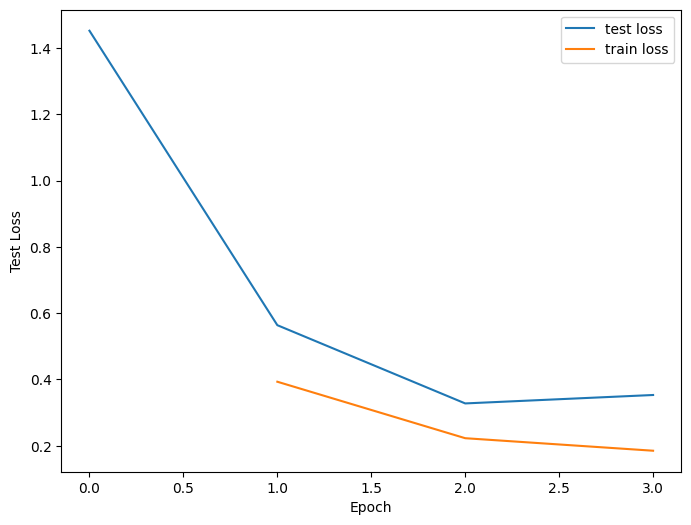

In [162]:
plt.figure(figsize=(8, 6))
plt.plot(range(4), quantum_loss_test, label='test loss')
plt.plot(range(1,4), quantum_loss_train, label='train loss')
plt.ylabel('Test Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

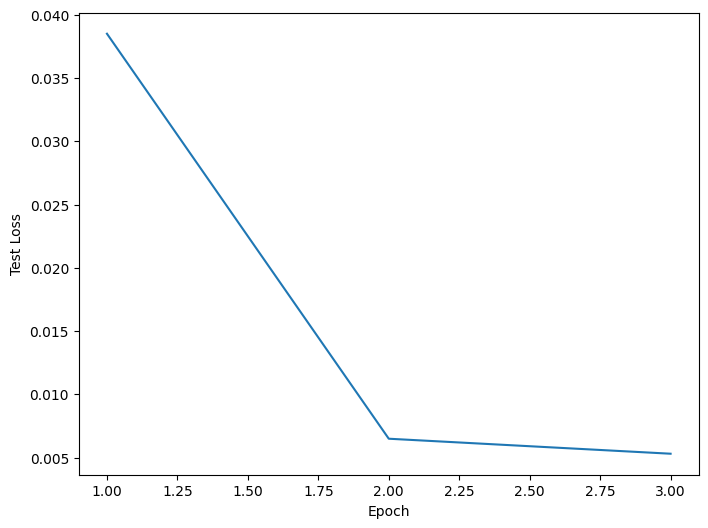

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(range(1,4), quantum_loss_train)
plt.ylabel('Test Loss')
plt.xlabel('Epoch')
plt.show()